In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import cvxpy as cp
import warnings
warnings.filterwarnings('ignore')

root        = '../'
data_file   = '03_data/data_for_experiments/'
output_file = '05_output/'
start_date  = '200101'
end_date    = '202412'

os.makedirs(root + output_file, exist_ok=True)

In [ ]:
# # creat small data samples
# root        = '../'
# data_file   = '03_data/'

# all_signals = pd.read_parquet(root + data_file + 'WRDS/all_signals.parquet')
# all_signals.rename(columns={'yyyymm': 'date'}, inplace=True)
# all_signals['date'] = all_signals['date'].astype(str)
# all_signals = all_signals[(all_signals['date'] >= start_date) & (all_signals['date'] <= end_date)]
# os.makedirs(root + data_file + 'data_for_experiments/', exist_ok=True)
# all_signals.to_pickle(root + data_file + 'data_for_experiments/all_signals.pickle')
# del all_signals
# print('signals done')

# crsp_d = pd.read_parquet(root + data_file + 'WRDS/crsp_d.parquet')
# crsp_d = crsp_d[(crsp_d['date'] >= start_date[:4] + '-' + start_date[4:] + '-01') & (crsp_d['date'] <= end_date[:4] + '-' + end_date[4:] + '-31')]
# crsp_d.reset_index(drop=True, inplace=True)
# crsp_d.to_pickle(root + data_file + 'data_for_experiments/stock_daily.pickle')
# del crsp_d
# print('stock done')

In [ ]:
# # generate monthly return data from daily return
# stock_daily = pd.read_pickle(root + data_file + 'stock_daily.pickle')
# stock_daily['month'] = stock_daily['date'].apply(lambda x: x[:7])
# stock_daily.sort_values(by=['permno', 'date'], inplace=True)
# stock_monthly = stock_daily.groupby(['permno', 'month']).agg(
#     ret       = ('ret',    'sum'),
#     prc       = ('prc',    'last'),
#     shrout    = ('shrout', 'last'),
#     vol       = ('vol',    'sum'),
#     shrcd     = ('shrcd',  'last'),
#     exchcd    = ('exchcd', 'last'),
# ).reset_index()
# stock_monthly['date'] = stock_monthly['month'].apply(lambda x: x.split('-')[0] + x.split('-')[1])
# stock_monthly = stock_monthly[['permno', 'date', 'ret', 'prc', 'shrout', 'vol', 'shrcd', 'exchcd']]
# os.makedirs(root + output_file + 'stock_monthly/', exist_ok=True)
# stock_monthly.to_pickle(root + output_file + 'stock_monthly/stock_monthly.pickle')

In [ ]:
# import wrds
# db = wrds.Connection(wrds_username = 'dunran')
# sp500list = db.raw_sql("SELECT * FROM crsp.dsp500list")

In [ ]:
signals = pd.read_pickle(root + data_file + 'all_signals.pickle')

In [335]:
stock_monthly = pd.read_pickle(root + output_file + 'stock_monthly/stock_monthly.pickle')
stock_monthly['mkcap'] = stock_monthly['prc'] * stock_monthly['shrout']
stock_monthly['mkcap_rank'] = stock_monthly.groupby(['date'])['mkcap'].rank(ascending = False)
stock_monthly = stock_monthly[(stock_monthly['mkcap_rank'] >= 0) & (stock_monthly['mkcap_rank'] <= 1000)]
# stock_monthly = stock_monthly[stock_monthly['permno'].isin(sp500list['permno'].tolist())]
stock_monthly = stock_monthly.merge(
    right = signals,
    on    = ['permno', 'date'],
    how   = 'left',
)
# cutoff_level = 0.1
# stock_monthly = stock_monthly.loc[:, stock_monthly.isnull().mean() <= cutoff_level].dropna(axis=0)

In [ ]:
# for i in range(1, 10):
#     print(f'cut in {i*0.1:.2f} generates {stock_monthly.loc[:, stock_monthly.isnull().mean() <= i*0.1].dropna(axis = 0)['permno'].nunique():5} stocks')

In [336]:
from scipy.optimize import minimize
def Equal_Weighted(returns_array):
    n_stocks = returns_array.shape[1]
    weight = 1.0 / n_stocks
    weights_col_vector = np.full((n_stocks, 1), weight)
    return weights_col_vector

def DRMV(returns, alpha_bar = 0.10 / 12, delta = 0.1, p = 2):
    n, d = returns.shape
    mu = np.mean(returns, axis=0)
    Sigma = returns.T @ returns / n
    V = Sigma - np.outer(mu, mu)
    
    def objective(phi):
        var_term = np.sqrt(phi.T @ V @ phi)
        reg_term = np.sqrt(delta) * np.linalg.norm(phi, ord=p)
        return float(var_term + reg_term)
    
    cons = [
        {'type': 'eq',   'fun': lambda phi: np.sum(phi) - 1.0},
        {'type': 'ineq', 'fun': lambda phi: mu @ phi - (alpha_bar + np.sqrt(delta) * np.linalg.norm(phi, ord=p))}
    ]
    
    res = minimize(objective, x0=np.ones(d)/d, method='SLSQP', constraints=cons,
        options={'disp': False, 'maxiter': 500, 'ftol': 1e-9},
        tol=1e-9
    )
    
    weights = res.x.reshape(-1, 1)
    weights = weights / np.sum(weights)
    return weights

In [338]:
DATE = stock_monthly['date'].sort_values().unique()
BACKTEST_START = DATE.min() 
BACKTEST_END   = '201912'
print(f'back test happens between {BACKTEST_START} and {BACKTEST_END}')
strategies = ['Single_Period_Markowitz', 'Equal_Weighted'] #+ [f'DRMV_\delta={i}' for i in [0.001, 0.005, 0.01]]

data = stock_monthly.pivot(index='date', columns='permno', values='ret')
data = data.sort_index()

back test happens between 200101 and 201912


In [339]:
stock_monthly['ret_pred'] = stock_monthly.groupby(['permno'])['ret'].rolling(120).mean().droplevel(0)
stock_monthly['ret_pred_error'] = np.abs(stock_monthly.groupby('permno')['ret'].shift(-1) - stock_monthly['ret_pred'])
import statsmodels.api as sm
params = []
rsquared = []
# tvalues = []
# nobs = []

characteristic = ['BM', 'Size', 'Mom12m', 'Beta', 'ReturnSkew', 'VolSD', 'IdioVol3F', 'EP']
for i, date in enumerate(DATE):
    if i <= 120 or stock_monthly[stock_monthly['date'] == date].dropna(subset=['ret_pred_error', *characteristic]).shape[0] == 0:
        continue
    print('\r', date, end = '')
    model = sm.OLS(
        endog=stock_monthly[stock_monthly['date'] == date].dropna(subset=['ret_pred_error', *characteristic])['ret_pred_error'], 
        exog=sm.add_constant(stock_monthly[stock_monthly['date'] == date].dropna(subset=['ret_pred_error', *characteristic])[characteristic])
    ).fit()
    params.append(model.params[characteristic])
    rsquared.append(model.rsquared)
    # tvalues.append(model.tvalues[characteristic])
    # nobs.append(model.nobs)

 202411

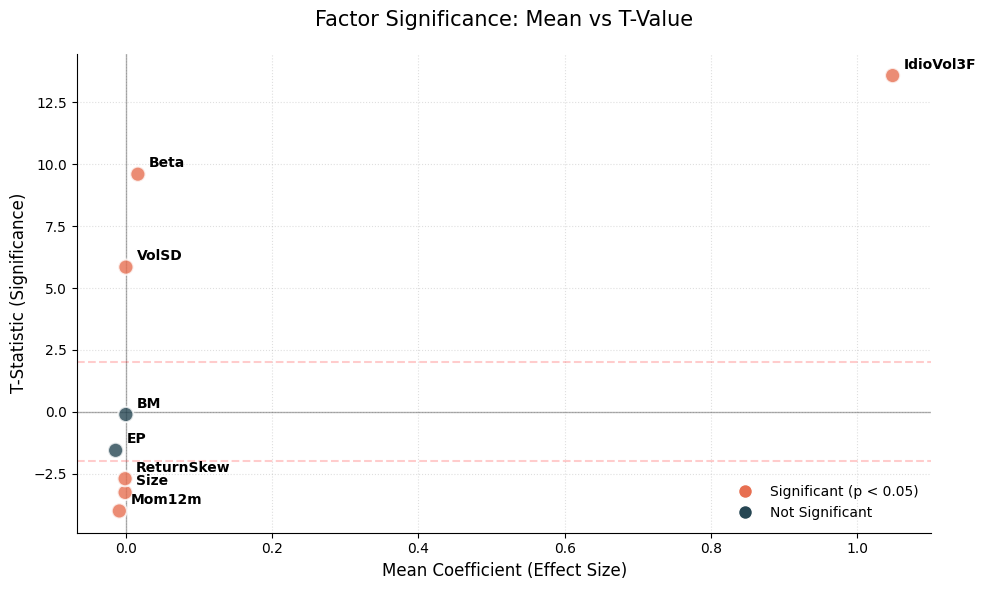

In [340]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

def plot_factor_analysis(series_list, expected_mean=0):
    """
    针对输入的 List[pd.Series] 自动提取变量并绘制 均值 vs T值 散点图
    """
    # 1. 将 List 合并为一个 DataFrame，每一列代表一个变量，每一行代表一次采样/时间点
    df = pd.DataFrame(series_list)
    
    means = []
    t_stats = []
    p_values = []
    variable_names = df.columns # 自动获取 BM, Size, Mom12m 等变量名
    
    # 2. 遍历每个变量计算统计量
    for col in variable_names:
        data = df[col].dropna() # 排除缺失值
        m = data.mean()
        t_stat, p_val = stats.ttest_1samp(data, expected_mean)
        
        means.append(m)
        t_stats.append(t_stat)
        p_values.append(p_val)
    
    # 3. 开始绘图
    plt.figure(figsize=(10, 6), dpi=100)
    
    # 区分显著性颜色：P < 0.05 为橘红色，否则为深蓝色
    colors = ['#e76f51' if p < 0.05 else '#264653' for p in p_values]
    
    # 绘制散点
    plt.scatter(means, t_stats, c=colors, s=120, alpha=0.8, edgecolor='white', linewidth=1.5, zorder=3)
    
    # 4. 添加标注（变量名）
    for i, name in enumerate(variable_names):
        plt.annotate(name, (means[i], t_stats[i]), xytext=(8, 5), 
                     textcoords='offset points', fontsize=10, fontweight='bold')
    
    # 5. 添加辅助线
    plt.axhline(0, color='black', lw=1, alpha=0.3) # 0基准线
    plt.axvline(0, color='black', lw=1, alpha=0.3) # 0均值线
    # 标注 T=2 临界线（约等于 p=0.05）
    plt.axhline(2, color='red', linestyle='--', alpha=0.2)
    plt.axhline(-2, color='red', linestyle='--', alpha=0.2)
    
    # 6. 美化细节
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.grid(True, linestyle=':', alpha=0.4, zorder=0)
    
    plt.title(f'Factor Significance: Mean vs T-Value', pad=20, fontsize=15)
    plt.xlabel('Mean Coefficient (Effect Size)', fontsize=12)
    plt.ylabel('T-Statistic (Significance)', fontsize=12)
    
    # 图例
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Significant (p < 0.05)', markerfacecolor='#e76f51', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Not Significant', markerfacecolor='#264653', markersize=10)
    ]
    plt.legend(handles=legend_elements, loc='best', frameon=False)

    plt.tight_layout()
    plt.show()

# --- 你可以直接这样调用 ---
plot_factor_analysis(params)

In [341]:
# from scipy import stats

# def perform_t_test(data, expected_mean=0):
#     # 执行单样本 t 检验
#     t_stat, p_value = stats.ttest_1samp(data, expected_mean)
    
#     print(f"--- 单样本 T 检验结果 ---")
#     print(f"T 统计量: {t_stat:.4f}")
#     print(f"P 值: {p_value:.4f}")
    
#     # 显著性水平通常取 0.05
#     if p_value < 0.01:
#         print("结论：在 0.01 显著性水平下，拒绝原假设（均值与预期有显著差异）。")
#     else:
#         print("结论：未能拒绝原假设（没有足够证据表明均值有显著差异）。")

# perform_t_test([t['ReturnSkew'] for t in tvalues], expected_mean=0)

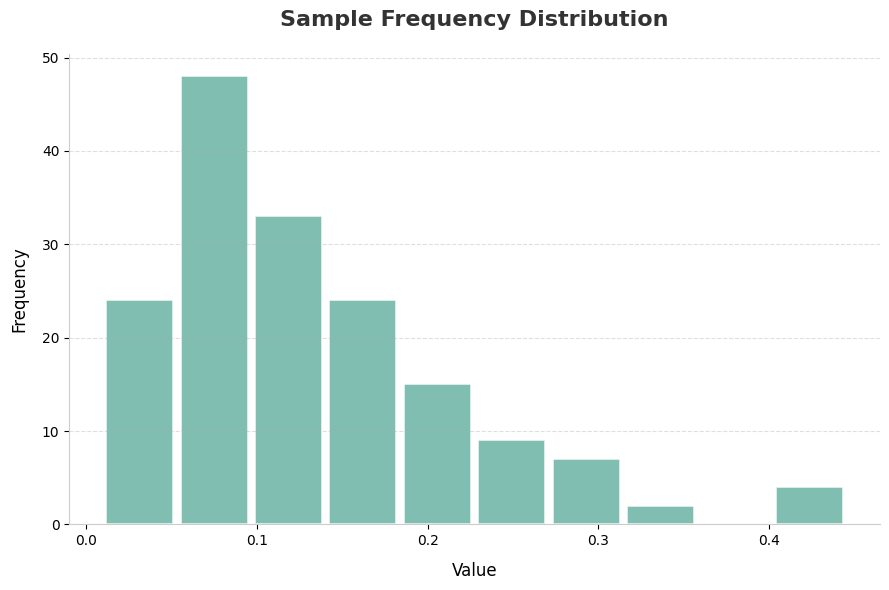

In [342]:

def plot_pretty_hist(data, title="Data Distribution", bins=None, color='#69b3a2'):
    # 1. 初始化画布
    fig, ax = plt.subplots(figsize=(9, 6), dpi=100)
    
    # 2. 绘制直方图
    # rwidth 控制柱子之间的间距，使其更有呼吸感
    n, bins_edges, patches = ax.hist(data, bins=bins, color=color, 
                                     edgecolor='white', linewidth=1.2, 
                                     alpha=0.85, rwidth=0.9)
    
    # 3. 细节美化
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0) # 背景网格
    ax.spines['top'].set_visible(False)   # 隐藏上边框
    ax.spines['right'].set_visible(False) # 隐藏右边框
    ax.spines['left'].set_color('#cccccc') # 变淡左边框
    ax.spines['bottom'].set_color('#cccccc')
    
    # 4. 标题与标签
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20, color='#333333')
    ax.set_xlabel('Value', fontsize=12, labelpad=10)
    ax.set_ylabel('Frequency', fontsize=12, labelpad=10)
    
    plt.tight_layout()
    plt.show()

plot_pretty_hist(rsquared, title="Sample Frequency Distribution")

In [355]:
iter_num = 10
portfolio_size = 50

signal = 'Size'
stock_monthly[signal + '_rank'] = stock_monthly.groupby(['date'])[signal].rank(pct=True)
signal_rank = stock_monthly.pivot(index='date', columns='permno', values=signal + '_rank')
signal_rank = signal_rank.sort_index()

In [356]:
port_ret = {s: [] for s in strategies}
for i, date in enumerate(DATE):
    if i + 120 + 1 >= len(DATE) or DATE[i+121] > BACKTEST_END:
        break
    print('\r', DATE[i+121], end = '')
    data_pool = data.iloc[i : i + 120 + 1]
    mask = (signal_rank.iloc[i + 120:i+120+1, :] >= 0.9).values.flatten()
    data_pool = data_pool.iloc[:, mask].dropna(axis=1)

    temp_sum = {s: 0.0 for s in strategies}
    
    for s in range(iter_num):
        data_cut = data_pool.sample(portfolio_size, axis=1, random_state=s).values
        train_data = data_cut[:-1, :]
        test_data  = data_cut[-1:, :]
        
        w_ew = Equal_Weighted(train_data)
        temp_sum['Equal_Weighted'] += (test_data @ w_ew)[0]
        
        w_spm = DRMV(train_data, 0.1/12, 0)
        temp_sum['Single_Period_Markowitz'] += (test_data @ w_spm)[0]
        
        # for j in [0.001, 0.005, 0.01]:
        #     key = f'DRMV_\delta={j}'
        #     w_drvm = DRMV(train_data, 0.1/12, 10**(-j))
        #     temp_sum[key] += (test_data @ w_drvm)[0]
            
    for s in strategies:
        port_ret[s].append(temp_sum[s] / iter_num)

 201912

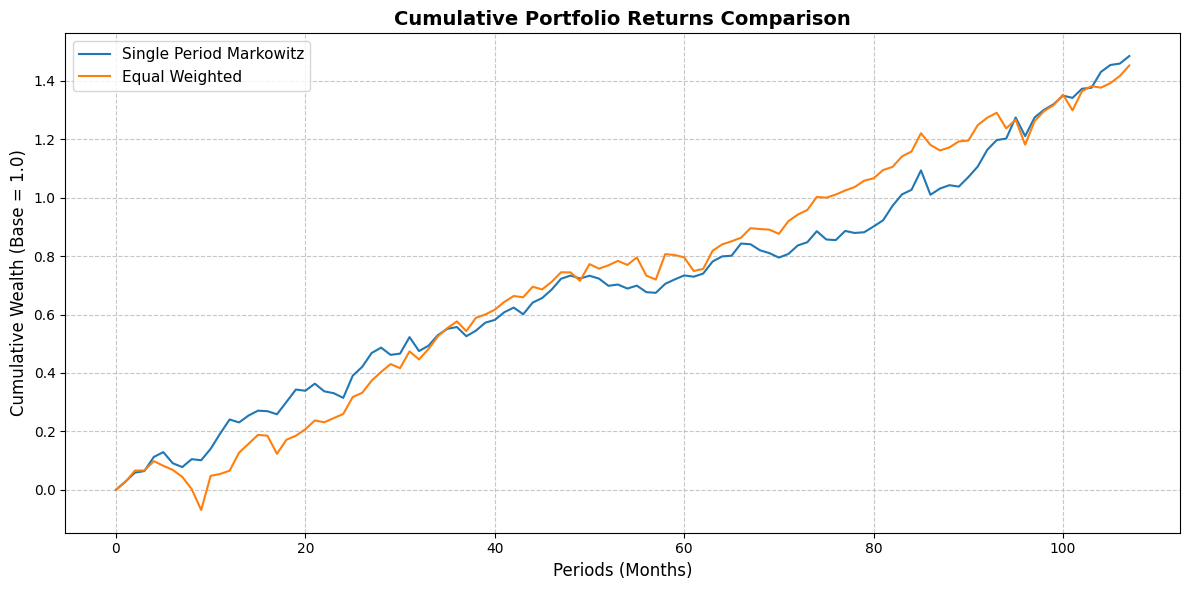

In [357]:
plt.figure(figsize=(12, 6), dpi=100)
for strategy_name, returns_list in port_ret.items():
    # if strategy_name in ['DRMV_\delta=1e-1', 'DRMV_\delta=1e-3']:
    #     continue
    returns_array = np.array(returns_list).flatten()
    cumulative_returns = np.cumsum(returns_array)
    cumulative_returns = np.insert(cumulative_returns, 0, 0)
    plt.plot(cumulative_returns, label=strategy_name.replace('_', ' '), linewidth=1.5)

plt.title('Cumulative Portfolio Returns Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Periods (Months)', fontsize=12)
plt.ylabel('Cumulative Wealth (Base = 1.0)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [358]:
df_ret = pd.DataFrame({
    k: np.ravel(v) for k, v in port_ret.items() if len(v) > 0
})

df_ret.index = pd.to_datetime(DATE[120:120+df_ret.shape[0]], format='%Y%m')

annual_rf = 0.02
months_in_year = 12

stats = pd.DataFrame(index=df_ret.columns)
stats['Annualized Mean'] = df_ret.mean() * months_in_year
stats['Annualized Volatility'] = df_ret.std() * np.sqrt(months_in_year)
stats['Sharpe Ratio'] = (stats['Annualized Mean'] - annual_rf) / stats['Annualized Volatility']

annual_returns_table = df_ret.groupby(df_ret.index.year).apply(lambda x: (x).sum())

# --- 4. 格式化输出 ---
print("----- 策略表现统计 (年化) -----")
print(stats.round(4))

print("\n----- 分年回报率 (年度累积) -----")
# 转置后行是方法，列是年份，更符合论文或报告格式
print(annual_returns_table.T.round(4))



----- 策略表现统计 (年化) -----
                        Annualized Mean Annualized Volatility Sharpe Ratio
Single_Period_Markowitz         0.16653              0.095677     1.531507
Equal_Weighted                 0.162887              0.114807     1.244588

----- 分年回报率 (年度累积) -----
                           2011    2012    2013    2014    2015    2016  \
Single_Period_Markowitz  0.2406  0.0740  0.2425  0.1762  0.0005  0.1028   
Equal_Weighted           0.0653  0.1942  0.3170  0.1677  0.0516  0.1465   

                           2017    2018    2019  
Single_Period_Markowitz  0.1901  0.1838  0.2743  
Equal_Weighted           0.2158  0.0235  0.2709  


In [359]:
port_ret = {s: [] for s in strategies}
for i, date in enumerate(DATE):
    if i + 120 + 1 >= len(DATE) or DATE[i+121] > BACKTEST_END:
        break
    print('\r', DATE[i+121], end = '')
    data_pool = data.iloc[i : i + 120 + 1]
    mask = (signal_rank.iloc[i + 120:i+120+1, :] <= 0.1).values.flatten()
    data_pool = data_pool.iloc[:, mask].dropna(axis=1)

    temp_sum = {s: 0.0 for s in strategies}
    
    for s in range(iter_num):
        data_cut = data_pool.sample(portfolio_size, axis=1, random_state=s).values
        train_data = data_cut[:-1, :]
        test_data  = data_cut[-1:, :]
        
        w_ew = Equal_Weighted(train_data)
        temp_sum['Equal_Weighted'] += (test_data @ w_ew)[0]
        
        w_spm = DRMV(train_data, 0.1/12, 0)
        temp_sum['Single_Period_Markowitz'] += (test_data @ w_spm)[0]
        
        # for j in [0.001, 0.005, 0.01]:
        #     key = f'DRMV_\delta={j}'
        #     w_drvm = DRMV(train_data, 0.1/12, 10**(-j))
        #     temp_sum[key] += (test_data @ w_drvm)[0]
            
    for s in strategies:
        port_ret[s].append(temp_sum[s] / iter_num)

 201102

ValueError: Cannot take a larger sample than population when 'replace=False'

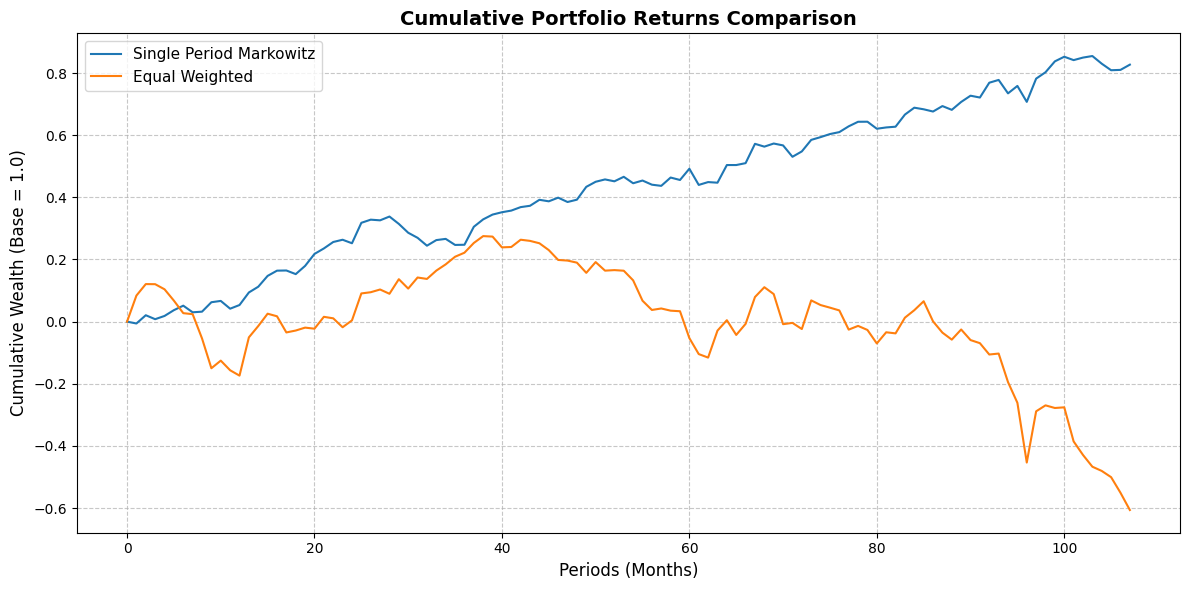

In [ ]:
plt.figure(figsize=(12, 6), dpi=100)
for strategy_name, returns_list in port_ret.items():
    # if strategy_name in ['DRMV_\delta=1e-1', 'DRMV_\delta=1e-3']:
    #     continue
    returns_array = np.array(returns_list).flatten()
    cumulative_returns = np.cumsum(returns_array)
    cumulative_returns = np.insert(cumulative_returns, 0, 0)
    plt.plot(cumulative_returns, label=strategy_name.replace('_', ' '), linewidth=1.5)

plt.title('Cumulative Portfolio Returns Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Periods (Months)', fontsize=12)
plt.ylabel('Cumulative Wealth (Base = 1.0)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_ret = pd.DataFrame({
    k: np.ravel(v) for k, v in port_ret.items() if len(v) > 0
})

df_ret.index = pd.to_datetime(DATE[120:120+df_ret.shape[0]], format='%Y%m')

annual_rf = 0.02
months_in_year = 12

stats = pd.DataFrame(index=df_ret.columns)

# 年化算术平均收益
stats['Annualized Mean'] = df_ret.mean() * months_in_year

# 年化标准差 (风险)
stats['Annualized Volatility'] = df_ret.std() * np.sqrt(months_in_year)

# 年化夏普比率
stats['Sharpe Ratio'] = (stats['Annualized Mean'] - annual_rf) / stats['Annualized Volatility']

annual_returns_table = df_ret.groupby(df_ret.index.year).apply(lambda x: (x).sum())

# --- 4. 格式化输出 ---
print("----- 策略表现统计 (年化) -----")
print(stats.round(4))

print("\n----- 分年回报率 (年度累积) -----")
# 转置后行是方法，列是年份，更符合论文或报告格式
print(annual_returns_table.T.round(4))



----- 策略表现统计 (年化) -----
                        Annualized Mean Annualized Volatility Sharpe Ratio
Single_Period_Markowitz        0.092732              0.079907       0.9102
Equal_Weighted                -0.067981              0.167301    -0.525883

----- 分年回报率 (年度累积) -----
                           2011    2012    2013   2014    2015    2016  \
Single_Period_Markowitz  0.0535  0.1987 -0.0048  0.145  0.0996  0.0558   
Equal_Weighted          -0.1737  0.1778  0.2177 -0.032 -0.2429  0.0293   

                           2017    2018    2019  
Single_Period_Markowitz  0.1407  0.0187  0.1197  
Equal_Weighted           0.0606 -0.4901 -0.1528  
